<a href="https://colab.research.google.com/github/lexatheo/neuro-fundamentals/blob/main/lif_neuron_population.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leaky Integrate-and-Fire Neuron
The leaky integrate-and-fire (LIF) model reduces a neuron to its membrane voltage. Input current pushes the voltage up (*integrate*). A constant leak pulls it back toward rest, so the neuron "forgets" non-continuous input (*leaky*). When the voltage crosses a threshold, the neuron emits a spike and resets (*fire*).
The model is governed by:

$$\tau_m \frac{dV}{dt} = -(V - V_{rest}) + RI$$

where $\tau_m$ is the membrane time constant (how fast the neuron leaks), $V_{rest}$ its resting voltage, $R$ the membrane resistance, and $I$ the input current. I integrate this forward in time using Euler's method.

In [44]:
import numpy as np
import matplotlib.pyplot as plt

#Neuron Parameters
tau_m = 10.0 # membrane time constant (ms)
V_rest = -70.0 # resting voltage (mV)
V_thres = -50.0 # firing threshold (mV)
V_reset = -65.0 # reset voltage (mV)
R = 1.0 # membrane resistance
I = 25.0 # input current

#Simulation Parameters
dt = 0.1 #timestep (ms)
T = 100.0 #total time (ms)

Here, I model a single neuron's membrane voltage over an interval of 100ms. With a constant input current, the voltage climbs toward threshold, fires, and resets at a steady rate, producing the characteristic sawtooth below. A stronger input current drives the voltage up faster, shortening the interval between spikes and raising the firing rate.

In [51]:
time = np.arange(0, T, dt) #time points from 0 to T in steps of dt
V_trace = []
spike_times = []

V = V_rest # start at resting voltage

for t in time:
    #Euler: leak term pulls V towards rest, R * I drives V up
    dV = (-(V - V_rest) + R * I) / tau_m * dt
    V = V + dV

    if V >= V_thres: # if threshold crossed, fire
        spike_times.append(t)
        V = V_reset #reset after spike

    V_trace.append(V)

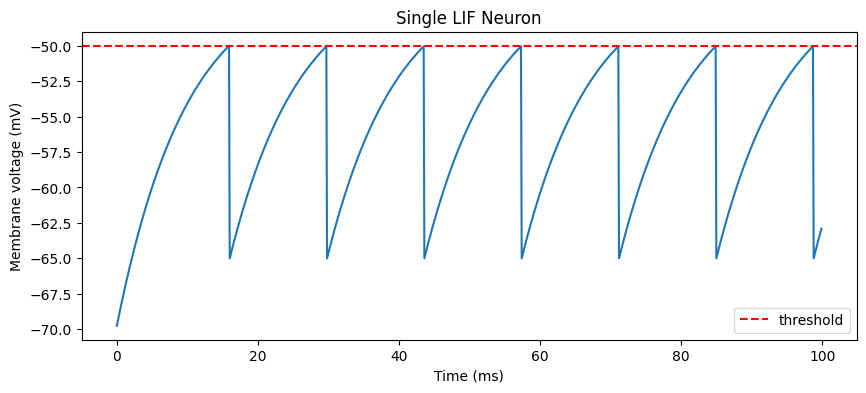

In [52]:
plt.figure(figsize=(10,4))
plt.plot(time, V_trace)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane voltage (mV)')
plt.axhline(V_thres, color ='red', linestyle='--', label = 'threshold')
plt.legend()
plt.title('Single LIF Neuron')
plt.show()


Below, I simulate a population of 20 neurons, giving each a slightly stronger input current than the last. Plotting every neuron's spikes as a raster shows how firing rate scales with input: neurons receiving more current (*top*) fire faster and more densely than those receiving less (*bottom*).

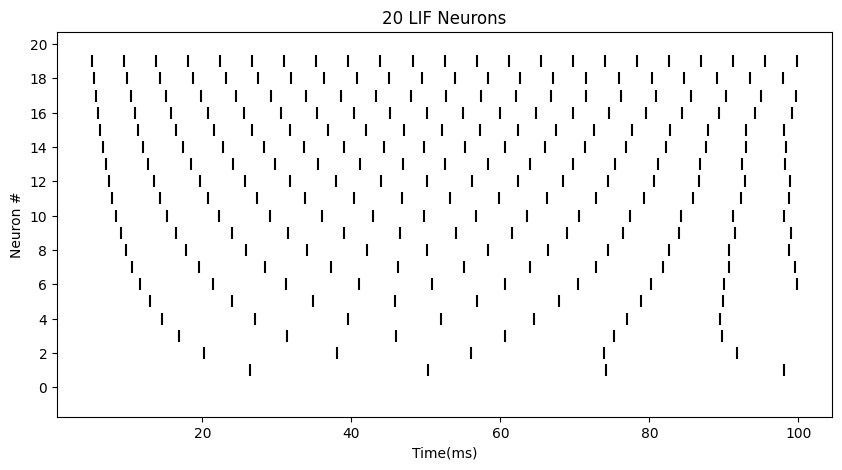

In [53]:
#Simulate one LIF w/constant input current, return spike times
def run_neuron(I):
  V = V_rest
  spikes = []
  for t in time:
      dV = (-(V - V_rest) + R * I)/ tau_m * dt
      V = V + dV
      if V >= V_thres:
        spikes.append(t)
        V = V_reset
  return spikes

# Simulate 20 neurons, each with progressively stronger input current
n_neurons = 20
population_spikes = []

for i in range(n_neurons):
  I_i = 20 + i * 1.5
  population_spikes.append(run_neuron(I_i))

#Raster plot: one row/neuron, tick per spike
plt.figure(figsize=(10,5))
plt.eventplot(population_spikes, colors='black', linelengths=0.7)
plt.xlabel('Time(ms)')
plt.ylabel('Neuron #')
plt.yticks(range(0, 21, 2))
plt.title('20 LIF Neurons')
plt.show()